In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df_train_DS=pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
df_train_DS.shape

(8693, 14)

In [41]:
df_test_DS=pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')
df_test_DS.shape

(4277, 13)

In [42]:
df_train_DS.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [43]:
df=pd.concat([df_train_DS,df_test_DS],ignore_index=True)

In [44]:
df.shape

(12970, 14)

In [45]:
df.isna().sum()

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
Transported     4277
dtype: int64

<Axes: >

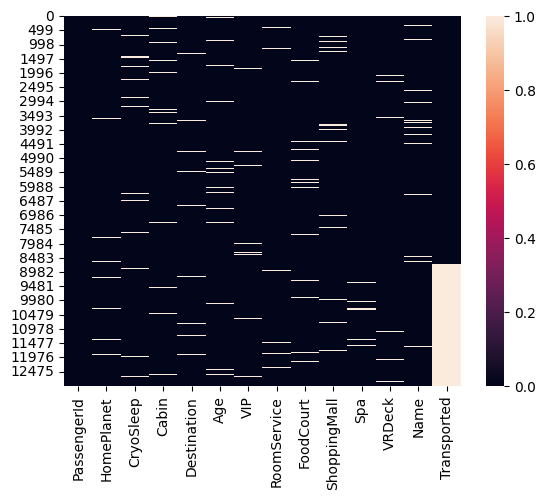

In [46]:
sns.heatmap(df.isna())

In [47]:
## lets clean the data
df['RoomService'].isna().sum()

263

In [48]:
df.shape

(12970, 14)

In [49]:
# HomePlanet-mode


In [50]:
df['Spa'].isna().sum()

284

In [51]:
df['Spa'].value_counts()

Spa
0.0       7935
1.0        218
2.0        148
3.0         82
4.0         73
          ... 
971.0        1
2290.0       1
1450.0       1
4517.0       1
1812.0       1
Name: count, Length: 1679, dtype: int64

In [52]:
df['Deck'] = df['Cabin'].str[0]
df['Side'] = df['Cabin'].str[-1]
df['Cabin_num'] = df['Cabin'].str.extract('(\d+)').astype(float)
df=df.drop(['Cabin','PassengerId','Name'],axis=1)

In [53]:

df['CryoSleep']=df['CryoSleep'].fillna(df['CryoSleep'].mode()[0]) 
df['VIP']=df['VIP'].fillna(df['VIP'].mode()[0]) 
df['Side']=df['Side'].fillna(df['Side'].mode()[0]) 

df['HomePlanet']=df['HomePlanet'].fillna(df['HomePlanet'].mode()[0]) 
df['Cabin_num']=df['Cabin_num'].fillna(df['Cabin_num'].mode()[0]) 

df['Deck']=df['Deck'].fillna(df['Deck'].mode()[0]) 

df['VRDeck']=df['VRDeck'].fillna(df['VRDeck'].mode()[0]) 

df['Spa']=df['Spa'].fillna(df['Spa'].mode()[0]) 

df['Age']=df['Age'].fillna(df['Age'].mean()) 
df['RoomService']=df['RoomService'].fillna(df['RoomService'].mean()) 
df['FoodCourt']=df['FoodCourt'].fillna(df['FoodCourt'].mean()) 
df['ShoppingMall']=df['ShoppingMall'].fillna(df['ShoppingMall'].mean()) 


# df['RoomServiceLog']=np.log1p(df['RoomService'])
# df['FoodCourtLog']=np.log1p(df['FoodCourt'])
# df['ShoppingMallLog']=np.log1p(df['ShoppingMall'])


# df=df.drop(['RoomService'],axis=1,errors='ignore')
# df=df.drop(['FoodCourtLog'],axis=1,errors='ignore')
# df=df.drop(['ShoppingMallLog'],axis=1,errors='ignore')

/tmp/ipykernel_37/3647912530.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CryoSleep']=df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
/tmp/ipykernel_37/3647912530.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP']=df['VIP'].fillna(df['VIP'].mode()[0])


In [54]:
log_features=['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
for col in log_features:
    
    df[col+"Log"]=np.log1p(df[col])

    df=df.drop([col],axis=1)


In [55]:
df['Side'].isna().sum()

0

In [56]:
df['Side'].value_counts()

Side
S    6680
P    6290
Name: count, dtype: int64

In [57]:
df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,Transported,Deck,Side,Cabin_num,RoomServiceLog,FoodCourtLog,ShoppingMallLog,SpaLog,VRDeckLog
0,Europa,False,TRAPPIST-1e,39.0,False,False,B,P,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,Earth,False,TRAPPIST-1e,24.0,False,True,F,S,0.0,4.700480,2.302585,3.258097,6.309918,3.806662
2,Europa,False,TRAPPIST-1e,58.0,True,False,A,S,0.0,3.784190,8.182280,0.000000,8.812248,3.912023
3,Europa,False,TRAPPIST-1e,33.0,False,False,A,S,0.0,0.000000,7.157735,5.918894,8.110728,5.267858
4,Earth,False,TRAPPIST-1e,16.0,False,True,F,S,1.0,5.717028,4.262680,5.023881,6.338594,1.098612


In [58]:
df['Destination'].value_counts()

Destination
TRAPPIST-1e      8871
55 Cancri e      2641
PSO J318.5-22    1184
Name: count, dtype: int64

In [59]:
df['Destination'].isna().sum()

274

In [60]:
df['Destination']=df['Destination'].fillna("MISSING")

In [61]:
# df['Des'].value_counts()

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   HomePlanet       12970 non-null  object 
 1   CryoSleep        12970 non-null  bool   
 2   Destination      12970 non-null  object 
 3   Age              12970 non-null  float64
 4   VIP              12970 non-null  bool   
 5   Transported      8693 non-null   object 
 6   Deck             12970 non-null  object 
 7   Side             12970 non-null  object 
 8   Cabin_num        12970 non-null  float64
 9   RoomServiceLog   12970 non-null  float64
 10  FoodCourtLog     12970 non-null  float64
 11  ShoppingMallLog  12970 non-null  float64
 12  SpaLog           12970 non-null  float64
 13  VRDeckLog        12970 non-null  float64
dtypes: bool(2), float64(7), object(5)
memory usage: 1.2+ MB


In [63]:
df['TotalSpending']=np.expm1(df['RoomServiceLog'])+np.expm1(df['FoodCourtLog'])+np.expm1(df['ShoppingMallLog'])+np.expm1(df['SpaLog'])+np.expm1(df['VRDeckLog'])
df['IsChild'] = (df['Age'] < 18).astype(int)


In [64]:
# HomePlanet,Destination, --categorical features
# ,VIP-binary


# Age-Numerical 
# RoomService,FoodCourt,ShoppingMall,Spa,VRDeck-skewed  & numercal as it bill amount
#  Cabin,Name,PassengerId-unwanted 

In [65]:
binary_cols = ['CryoSleep','VIP','Transported']
# RoomService,FoodCourt,ShoppingMall,Spa,VRDeck-skewed  & numercal as it bill amount

for col in binary_cols:
    df[col]=df[col].map({True:1,False:0})

df['Side']=df['Side'].map({'P':1,'S':0})

    



In [66]:
df_trainclean_DS=df[:8693]
df_testclean_DS=df[8693:]

In [67]:
X=df_trainclean_DS.drop('Transported',axis=1)
y=df_trainclean_DS['Transported']


In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
numerical_features=['Age','RoomServiceLog','FoodCourtLog','ShoppingMallLog','SpaLog','VRDeckLog']
categorical_features=['HomePlanet','Destination']

transformer=ColumnTransformer([
    ('cat',OneHotEncoder(),categorical_features),
    ('num',StandardScaler(),numerical_features)
])

transformed_train_x=transformer.fit_transform(X)
transformed_test_x=transformer.transform(df_testclean_DS)

In [69]:
from sklearn.ensemble import RandomForestClassifier

RFModel=RandomForestClassifier()

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(transformed_train_x,y,test_size=0.2,random_state=42)



RFModel.fit(X_train,y_train)
RFModel.score(X_test,y_test)

0.7665324899367453

In [70]:
from xgboost import XGBClassifier
bstModel = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
bstModel.fit(X_train,y_train)
bstModel.score(X_test,y_test)

0.7613571017826337

In [86]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

# 🔹 Define models in a dictionary
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200,max_depth=50),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=20, learning_rate=0.05, subsample=0.8,colsample_bytree=0.8,objective='binary:logistic',eval_metric='logloss'),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    err = 1 - acc
    results[name] = {"Accuracy": acc, "Error Rate": err}

# 🔹 Show results
for name, metrics in results.items():
    print(f"{name}: Accuracy = {metrics['Accuracy']:.3f}, Error Rate = {metrics['Error Rate']:.3f}")

RandomForest: Accuracy = 0.765, Error Rate = 0.235
XGBoost: Accuracy = 0.773, Error Rate = 0.227
DecisionTree: Accuracy = 0.731, Error Rate = 0.269
KNN: Accuracy = 0.757, Error Rate = 0.243


##### 

In [89]:
param_grid={
    'n_estimators':[100,200,300],
     'max_depth':[5,20,30],
    'learning_rate':[0.1,0.03,0.5],
    'subsample':[0.2,0.5,0.8],
    'colsample_bytree':[0.2,0.5,0.8],
    'objective':['binary:logistic'],
    'eval_metric':['logloss']
    
}

In [90]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Fitting 3 folds for each of 243 candidates, totalling 729 fits
[CV] END colsample_bytree=0.2, eval_metric=logloss, learning_rate=0.1, max_depth=5, n_estimators=100, objective=binary:logistic, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, eval_metric=logloss, learning_rate=0.1, max_depth=5, n_estimators=100, objective=binary:logistic, subsample=0.5; total time=   0.1s
[CV] END colsample_bytree=0.2, eval_metric=logloss, learning_rate=0.1, max_depth=5, n_estimators=100, objective=binary:logistic, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, eval_metric=logloss, learning_rate=0.1, max_depth=5, n_estimators=200, objective=binary:logistic, subsample=0.2; total time=   0.3s
[CV] END colsample_bytree=0.2, eval_metric=logloss, learning_rate=0.1, max_depth=5, n_estimators=200, objective=binary:logistic, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.2, eval_metric=logloss, learning_rate=0.1, max_depth=5, n_estimators=300, objective=binary:log

In [91]:
grid_search.best_params_

{'colsample_bytree': 0.5,
 'eval_metric': 'logloss',
 'learning_rate': 0.03,
 'max_depth': 5,
 'n_estimators': 300,
 'objective': 'binary:logistic',
 'subsample': 0.2}

SyntaxError: invalid syntax (1937477076.py, line 1)

In [98]:
# 5️⃣ Train final model with best params on full training data
best_xgb = XGBClassifier(**grid_search.best_params_)
best_xgb.fit(X_train, y_train)

# 6️⃣ Evaluate on test data
y_pred = best_xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.3f}")


Test Accuracy: 0.781


In [99]:
best_xgb.score(X_test,y_test)

0.7814836112708453

In [100]:
from sklearn.metrics import accuracy_score

# 5️⃣ Train final model with best params on full training data
best_xgb = XGBClassifier(**grid_search.best_params_)
best_xgb.fit(X_train, y_train)

# 6️⃣ Evaluate on training data
y_train_pred = best_xgb.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# 7️⃣ Evaluate on test data
y_test_pred = best_xgb.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

# 8️⃣ Print results
print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

# 9️⃣ Rough bias-variance check
if train_acc < 0.7 and test_acc < 0.7:
    print("High Bias → Model is underfitting")
elif train_acc - test_acc > 0.1:
    print("High Variance → Model is overfitting")
else:
    print("Balanced → Good generalization")


Train Accuracy: 0.816
Test Accuracy: 0.781
Balanced → Good generalization


In [104]:
df_test_DS['PassengerId']

0       0013_01
1       0018_01
2       0019_01
3       0021_01
4       0023_01
         ...   
4272    9266_02
4273    9269_01
4274    9271_01
4275    9273_01
4276    9277_01
Name: PassengerId, Length: 4277, dtype: object

In [105]:
# PassengerId,Transported
y_test_preds=best_xgb.predict(transformed_test_x)
submission=pd.DataFrame({
    'PassengerId':df_test_DS['PassengerId'],
    'Transported':y_test_preds
}) 
submission.to_csv('submission.csv',index=False)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices